# Assignment 2: Quantum Phase Estimation — IBM Quantum Hardware Version

**Parameters:** θ = 0.5, t = 5

This notebook converts the simulator-only QPE assignment into a hardware-execution version using the current IBM Quantum / Qiskit Runtime workflow.

This version is for the research question:

> Does requiring real quantum hardware execution create meaningful student verification beyond what ChatGPT can predict?

The notebook includes:
1. QPE circuit construction
2. Circuit image using `.draw('mpl')`
3. IBM Quantum Runtime setup
4. Real backend selection
5. Hardware execution with default settings
6. Hardware execution with additional error-suppression settings
7. Histograms
8. Calculation of θ from measured hardware results
9. Evidence fields: backend, job IDs, shots, dominant bitstrings

You need an IBM Quantum account/API token to run the hardware cells.

In [ ]:
!pip install qiskit qiskit-ibm-runtime matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha

In [ ]:
# Install if needed in a fresh environment:
# !pip install qiskit qiskit-ibm-runtime matplotlib pylatexenc

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

/tmp/ipykernel_14449/115058013.py:25: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=t, inverse=True, do_swaps=True).decompose()


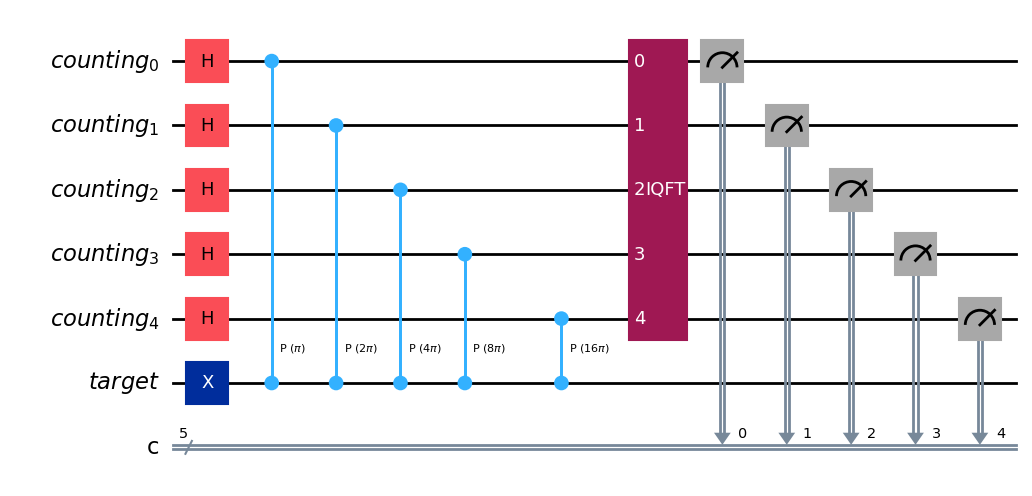

In [ ]:
# Assignment parameters
theta = 0.5
t = 5
shots = 1024

# Registers: t counting qubits + 1 eigenstate qubit
counting = QuantumRegister(t, "counting")
target = QuantumRegister(1, "target")
c = ClassicalRegister(t, "c")
qc = QuantumCircuit(counting, target, c)

# Prepare eigenstate |1> for the phase gate U = P(2*pi*theta)
qc.x(target[0])

# Put counting register into superposition
for q in counting:
    qc.h(q)

# Controlled-U^(2^j), where U|1> = exp(2*pi*i*theta)|1>
for j in range(t):
    angle = 2 * np.pi * theta * (2 ** j)
    qc.cp(angle, counting[j], target[0])

# Inverse QFT on the counting register
iqft = QFT(num_qubits=t, inverse=True, do_swaps=True).decompose()
qc.append(iqft, counting)

# Measure counting register
qc.measure(counting, c)

qc.draw("mpl")

## IBM Quantum account setup

Run this once locally/privately if your IBM Quantum account is not already saved.

Do **not** submit a notebook containing your real API token.

```python
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="F2xP9k3pzI_zY9-0-jEVC8M317J1T7e8ZtlKUp3nTLqZ",
    overwrite=True
)
```

After the account is saved, use:

```python
service = QiskitRuntimeService()
```

In [ ]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="",
    overwrite=True
)

In [ ]:
# Load saved IBM Quantum account
service = QiskitRuntimeService()

# Choose the least busy operational real quantum backend.
# This intentionally excludes simulators.
backend = service.least_busy(operational=True, simulator=False)

print("Selected backend:", backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-23 21:26:56,707: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 21:26:57,007: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-23 21:26:59,145: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh


Original circuit depth: 8
ISA/transpiled circuit depth: 145


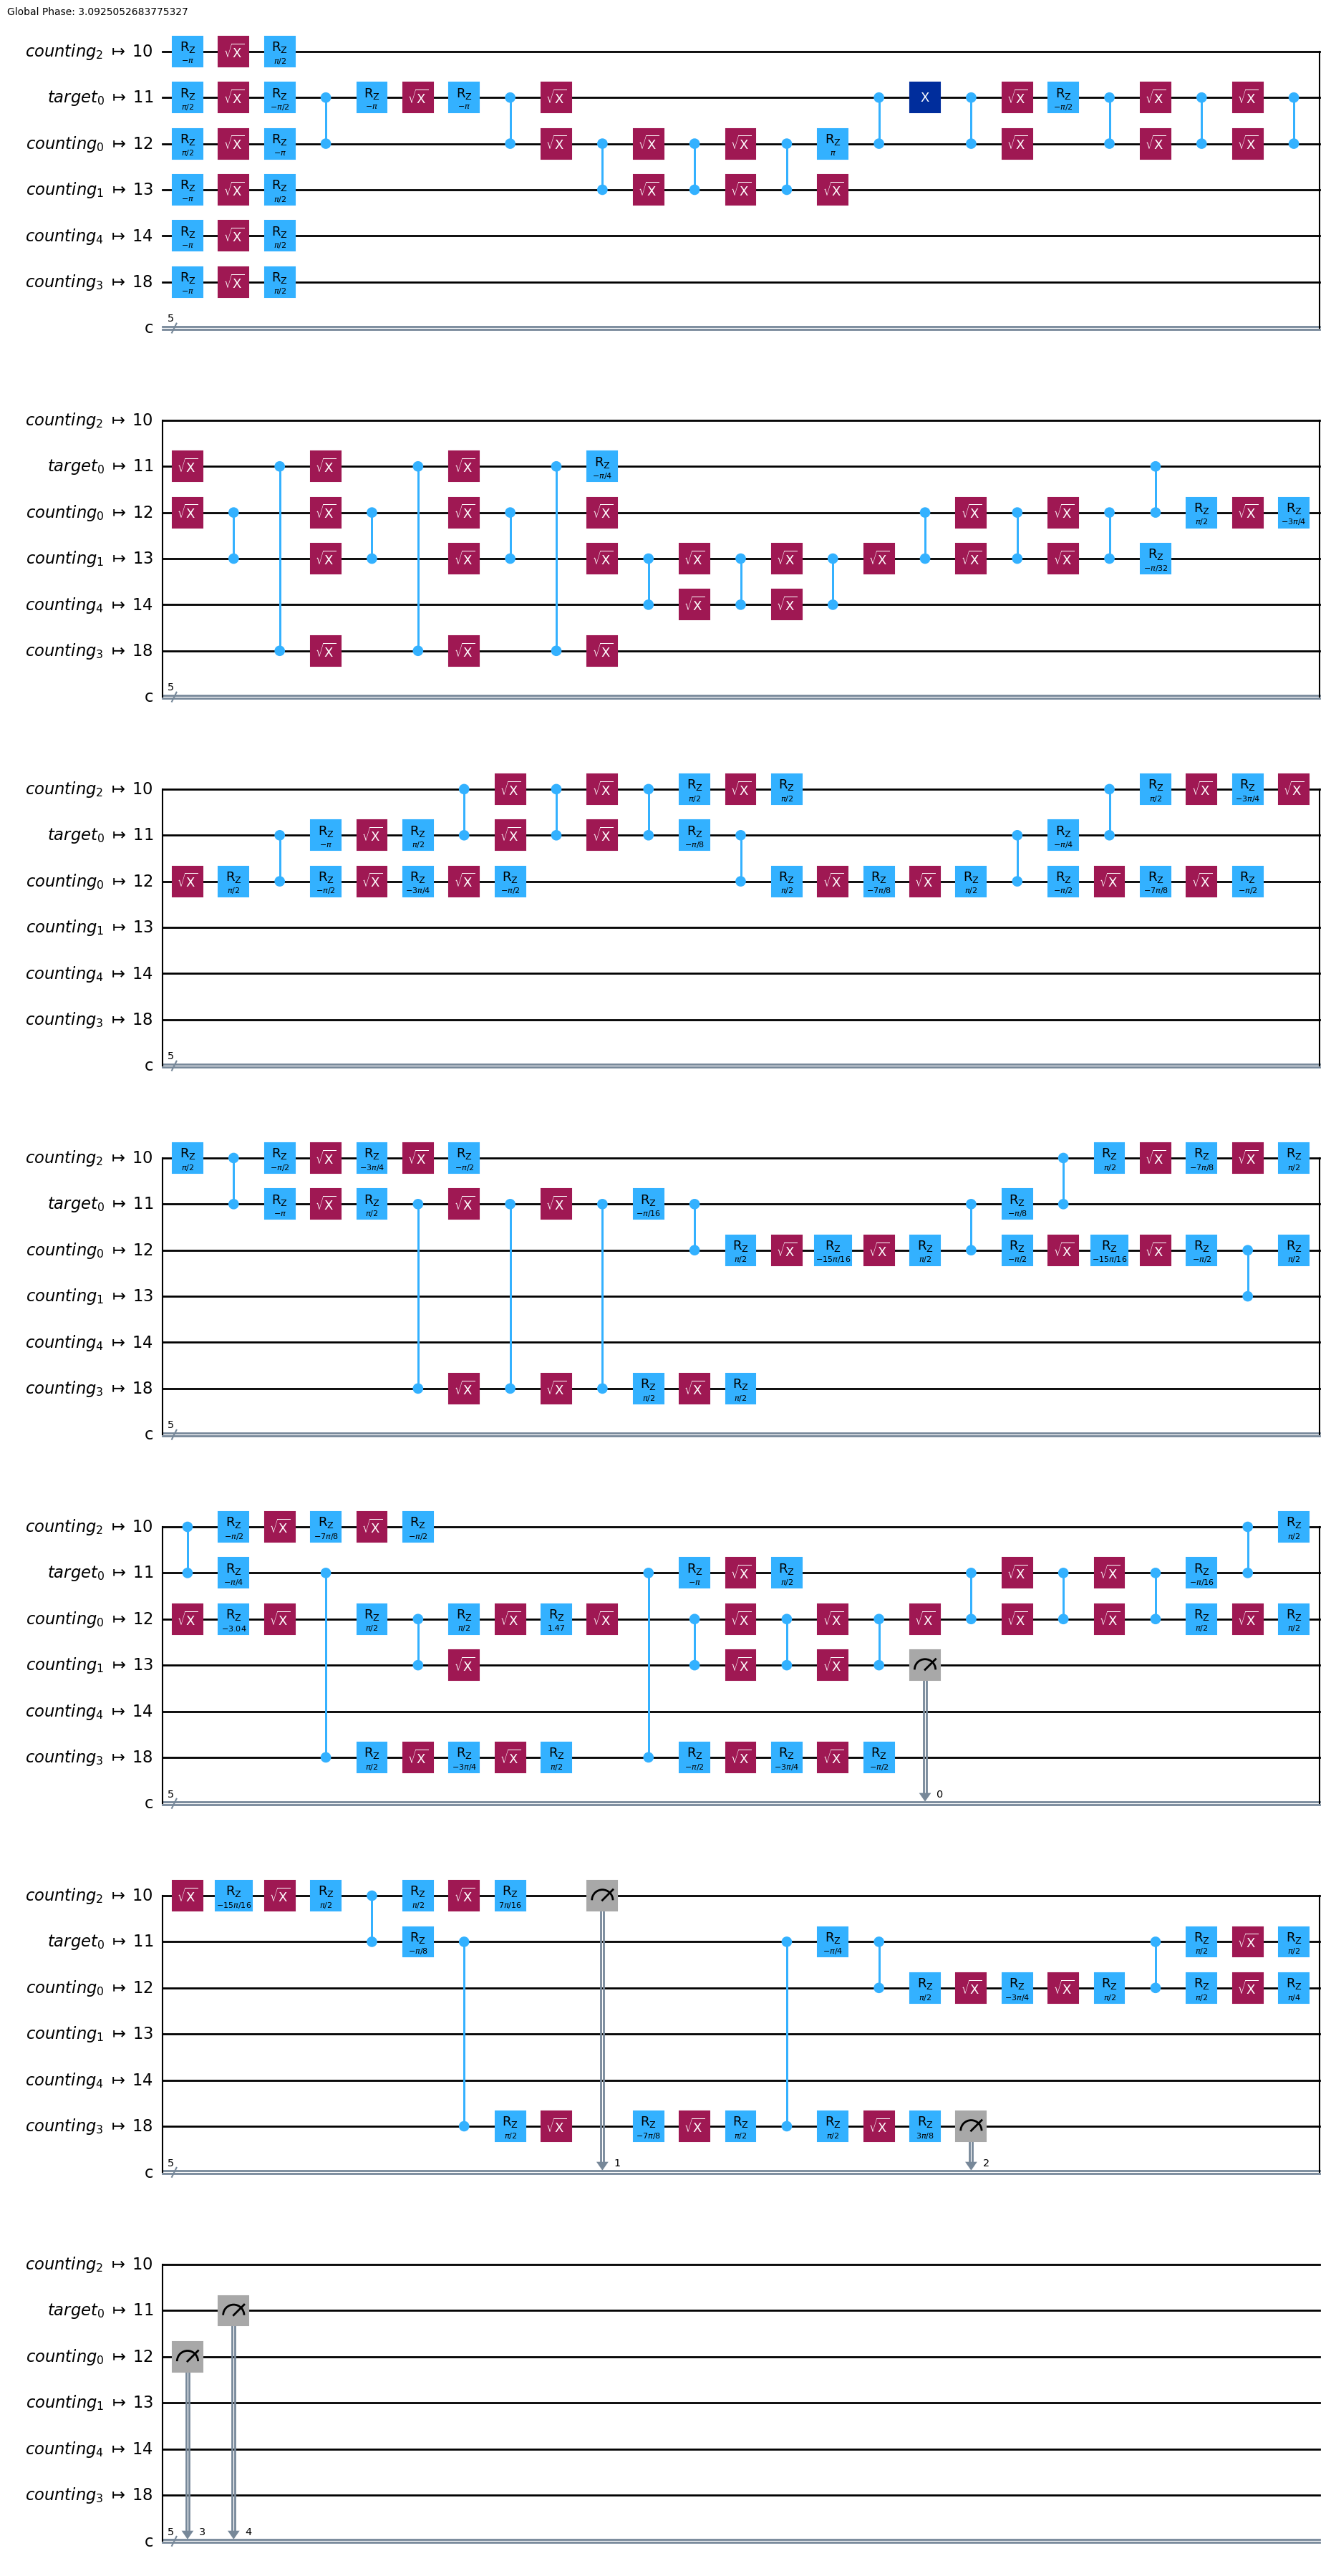

In [ ]:
# Transpile / optimize the circuit for the selected backend.
# IBM's current pattern is: map problem -> optimize circuit -> execute using primitive -> analyze result.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

print("Original circuit depth:", qc.depth())
print("ISA/transpiled circuit depth:", isa_qc.depth())
isa_qc.draw("mpl", idle_wires=False)

Default hardware job ID: d8tfkf4bp3hs7384fss0
Backend: ibm_marrakesh
Shots: 1024
Default hardware counts: {'00001': 14, '10000': 725, '11000': 31, '10010': 22, '01000': 29, '10110': 6, '11110': 5, '00011': 2, '01111': 6, '01110': 12, '01100': 10, '10001': 18, '00000': 67, '10100': 27, '01101': 4, '00010': 2, '10111': 3, '00100': 5, '01010': 6, '01001': 5, '10011': 3, '11001': 3, '11100': 1, '00110': 3, '11010': 4, '11111': 2, '00111': 2, '11011': 2, '00101': 2, '01011': 2, '11101': 1}


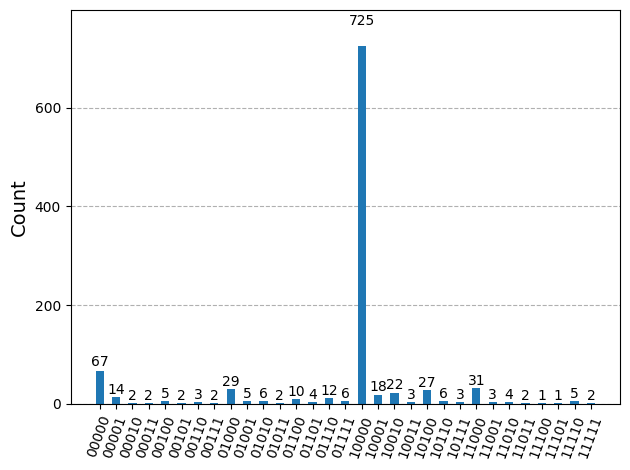

In [ ]:
# Hardware run 1: default SamplerV2 execution

sampler_default = Sampler(mode=backend)
job_default = sampler_default.run([isa_qc], shots=shots)

print("Default hardware job ID:", job_default.job_id())
print("Backend:", backend.name)
print("Shots:", shots)

result_default = job_default.result()
pub_result_default = result_default[0]

# Because the classical register is named 'c', retrieve counts from pub_result_default.data.c
counts_default = pub_result_default.data.c.get_counts()

print("Default hardware counts:", counts_default)
plot_histogram(counts_default)

In [ ]:
# Calculation from default hardware result

dominant_default = max(counts_default, key=counts_default.get)
m_default = int(dominant_default, 2)
theta_default = m_default / (2 ** t)

print(f"Default hardware dominant bitstring: {dominant_default}")
print(f"Measured integer: {m_default}")
print(f"theta estimate = {m_default} / {2 ** t} = {theta_default}")

Default hardware dominant bitstring: 10000
Measured integer: 16
theta estimate = 16 / 32 = 0.5


Suppressed hardware job ID: d8tflvcbp3hs7384fv3g
Backend: ibm_marrakesh
Shots: 1024
Suppressed hardware counts: {'10000': 730, '01000': 26, '00000': 34, '11101': 2, '10010': 22, '10001': 22, '01100': 14, '00010': 4, '10100': 28, '01110': 24, '10011': 4, '10101': 4, '00100': 4, '00001': 10, '00011': 3, '01001': 4, '11010': 3, '11100': 5, '01111': 13, '11000': 25, '11111': 6, '10111': 2, '11001': 6, '01011': 1, '10110': 7, '11011': 3, '01101': 4, '00110': 7, '01010': 4, '00111': 1, '11110': 2}


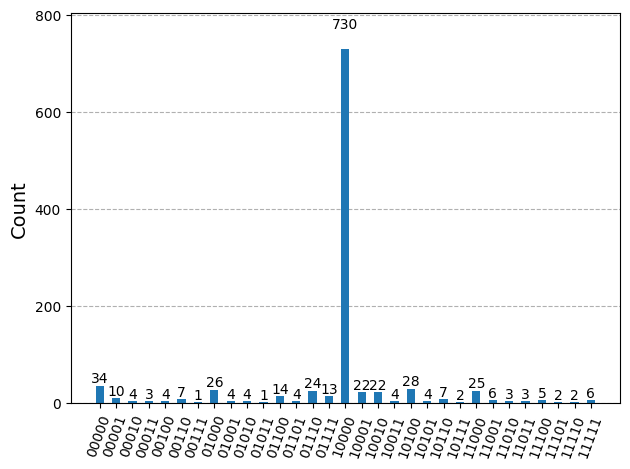

In [ ]:
# Hardware run 2: SamplerV2 with additional error-suppression settings.
# SamplerV2 does not use a simple resilience_level setting like Estimator workflows.
# For Sampler workflows, individual suppression methods can be turned on.

sampler_suppressed = Sampler(mode=backend)

# Dynamical decoupling can help suppress idle-time errors.
sampler_suppressed.options.dynamical_decoupling.enable = True
sampler_suppressed.options.dynamical_decoupling.sequence_type = "XY4"

# Gate twirling randomizes coherent errors into stochastic-like errors.
# Availability can depend on current Runtime/client options.
sampler_suppressed.options.twirling.enable_gates = True
sampler_suppressed.options.twirling.num_randomizations = "auto"

job_suppressed = sampler_suppressed.run([isa_qc], shots=shots)

print("Suppressed hardware job ID:", job_suppressed.job_id())
print("Backend:", backend.name)
print("Shots:", shots)

result_suppressed = job_suppressed.result()
pub_result_suppressed = result_suppressed[0]
counts_suppressed = pub_result_suppressed.data.c.get_counts()

print("Suppressed hardware counts:", counts_suppressed)
plot_histogram(counts_suppressed)

In [ ]:
# Calculation from suppressed hardware result

dominant_suppressed = max(counts_suppressed, key=counts_suppressed.get)
m_suppressed = int(dominant_suppressed, 2)
theta_suppressed = m_suppressed / (2 ** t)

print(f"Suppressed hardware dominant bitstring: {dominant_suppressed}")
print(f"Measured integer: {m_suppressed}")
print(f"theta estimate = {m_suppressed} / {2 ** t} = {theta_suppressed}")

Suppressed hardware dominant bitstring: 10000
Measured integer: 16
theta estimate = 16 / 32 = 0.5


## Expected theoretical result

With t = 5:

2^t = 32

For θ = 0.5:

θ × 32 = 16

16 in 5-bit binary is 10000.

Therefore, the ideal dominant bitstring is **10000**, giving:

θ = 16 / 32 = 0.5

## Hardware interpretation

The hardware result is not expected to be perfectly deterministic. The important questions are:

1. Is **10000** still the dominant or near-dominant outcome?
2. Is the resulting θ estimate close to 0.5?
3. Does the error-suppressed run improve the distribution compared with the default hardware run?
4. Is the hardware result meaningful enough for a student assignment?
5. Does the job ID/backend/count distribution provide evidence that the student actually ran the hardware computation?

## Evidence to record

Fill this in after running:

- Backend used:
- Default hardware job ID:
- Suppressed hardware job ID:
- Shots:
- Default dominant bitstring:
- Default θ estimate:
- Suppressed dominant bitstring:
- Suppressed θ estimate:
- Was the hardware result meaningfully close to 0.5?
- Did the hardware result provide student-specific verification evidence?